# Student Health Risk — Exploratory Data Analysis

Standalone visual EDA notebook for the `train.csv` dataset. This complements `student_health_risk.ipynb` (the full modeling pipeline) by collecting every exploratory chart in one place, with extra views (violin plots, pairwise scatter, missingness pattern) not in the modeling notebook.

## 1. Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

TARGET = 'health_condition'
CLASS_ORDER = ['fit', 'at-risk', 'unhealthy']
PALETTE = dict(zip(CLASS_ORDER, sns.color_palette('Set2', len(CLASS_ORDER))))

NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']
CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']

## 2. Load Data

In [ ]:
DATA_DIR = '../data' if os.path.exists('../data') else '/kaggle/input/playground-series-s5e6'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
print(f'Train shape: {train.shape}')
train.head()

## 3. Dataset Overview

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [4]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


## 4. Missing Values

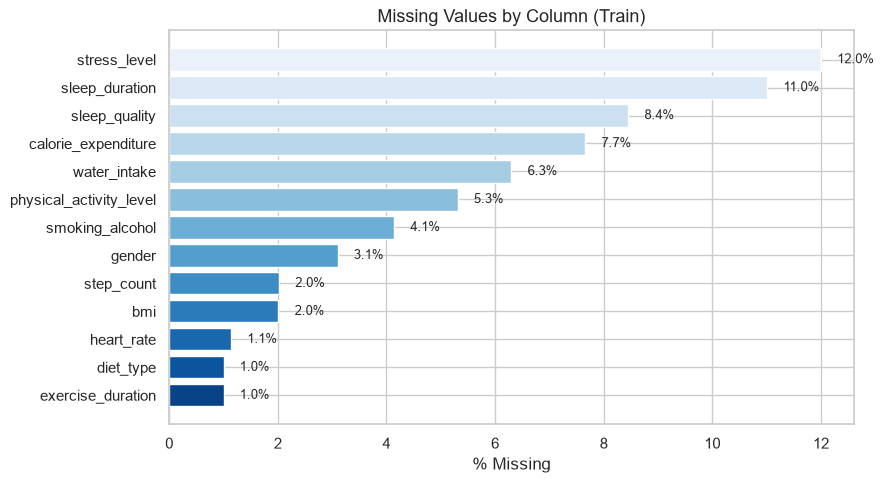

In [5]:
miss = train.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
pct = (miss / len(train) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(miss.index[::-1], pct.values[::-1], color=sns.color_palette('Blues_r', len(miss)))
for bar, v in zip(bars, pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column (Train)', fontsize=13)
plt.tight_layout()
plt.show()

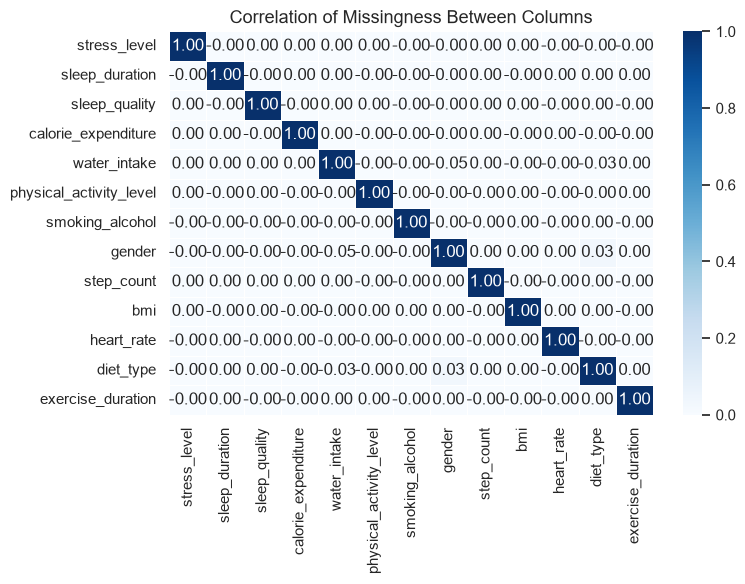

In [6]:
# Missingness pattern — is missingness correlated across columns?
miss_cols = miss.index.tolist()
miss_mask = train[miss_cols].isnull().astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(miss_mask.corr(), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation of Missingness Between Columns', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Target Distribution

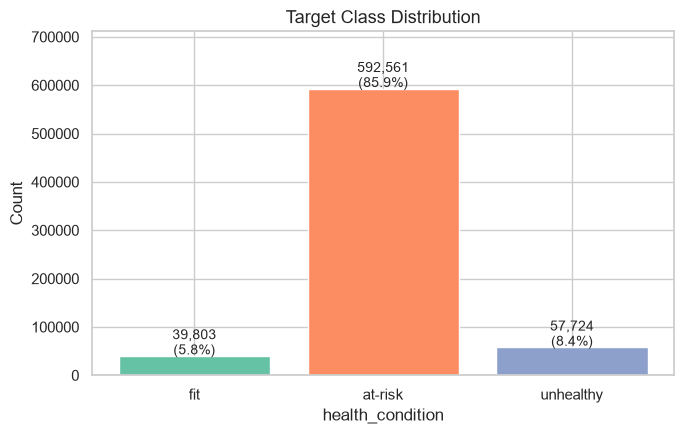

Class imbalance ratio (majority:minority) = 14.9 : 1


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
vc = train[TARGET].value_counts().reindex(CLASS_ORDER)
colors = [PALETTE[c] for c in vc.index]
ax.bar(vc.index, vc.values, color=colors)
for i, (k, v) in enumerate(vc.items()):
    ax.text(i, v + len(train) * 0.005, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution', fontsize=13)
ax.set_xlabel(TARGET)
ax.set_ylabel('Count')
ax.set_ylim(0, vc.max() * 1.2)
plt.tight_layout()
plt.show()
print('Class imbalance ratio (majority:minority) = '
      f'{vc.max() / vc.min():.1f} : 1')

## 6. Numeric Feature Distributions (Overall)

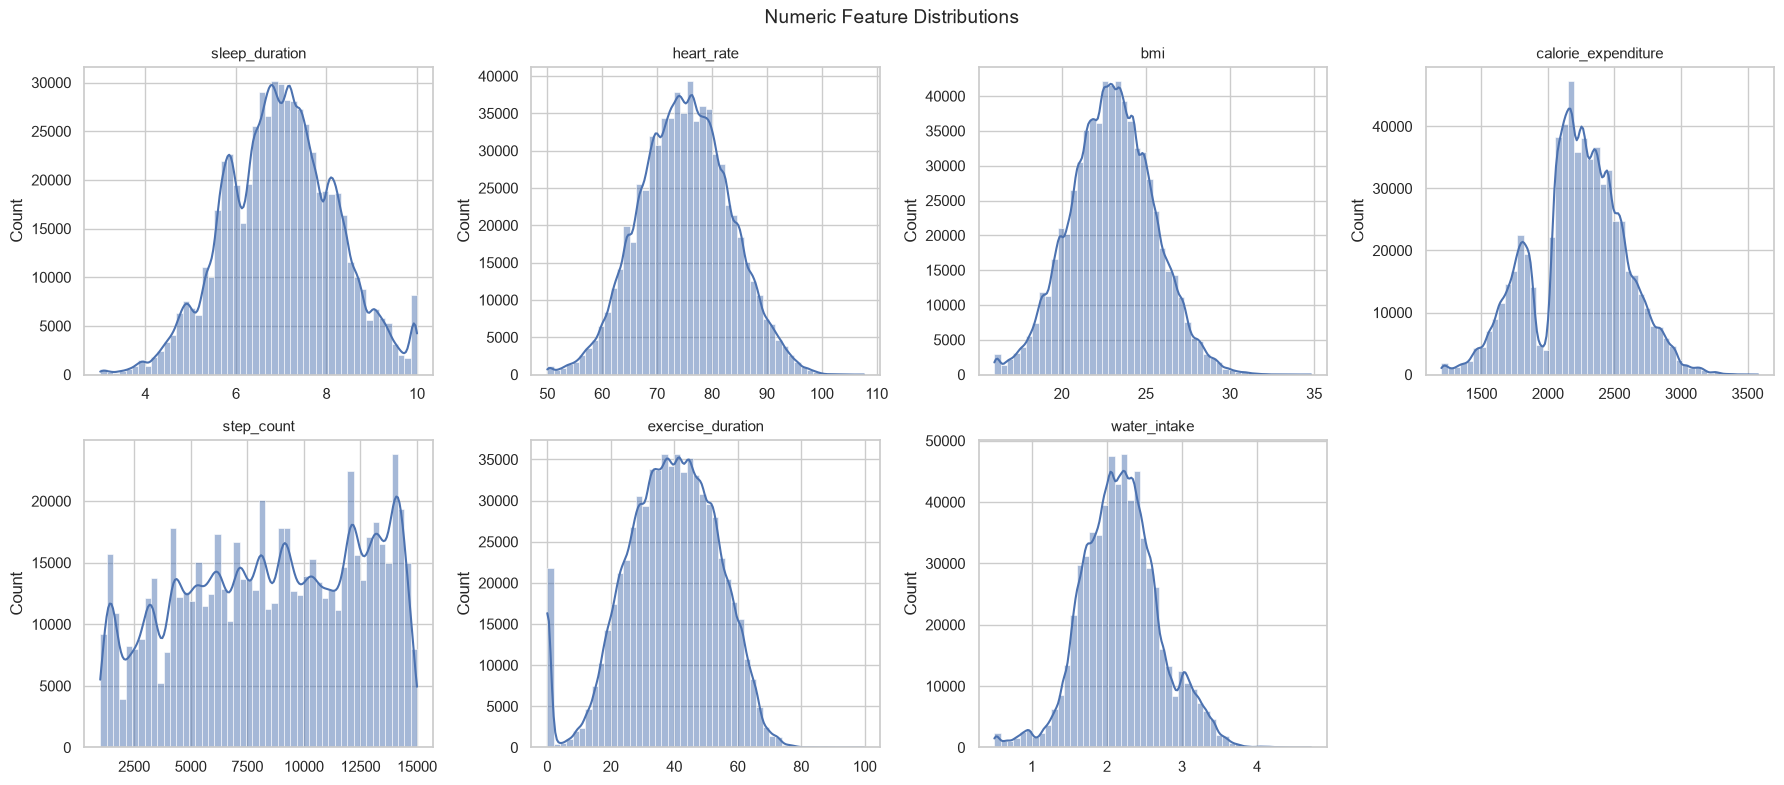

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    sns.histplot(train[col].dropna(), bins=50, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
fig.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Numeric Features by Target — Density

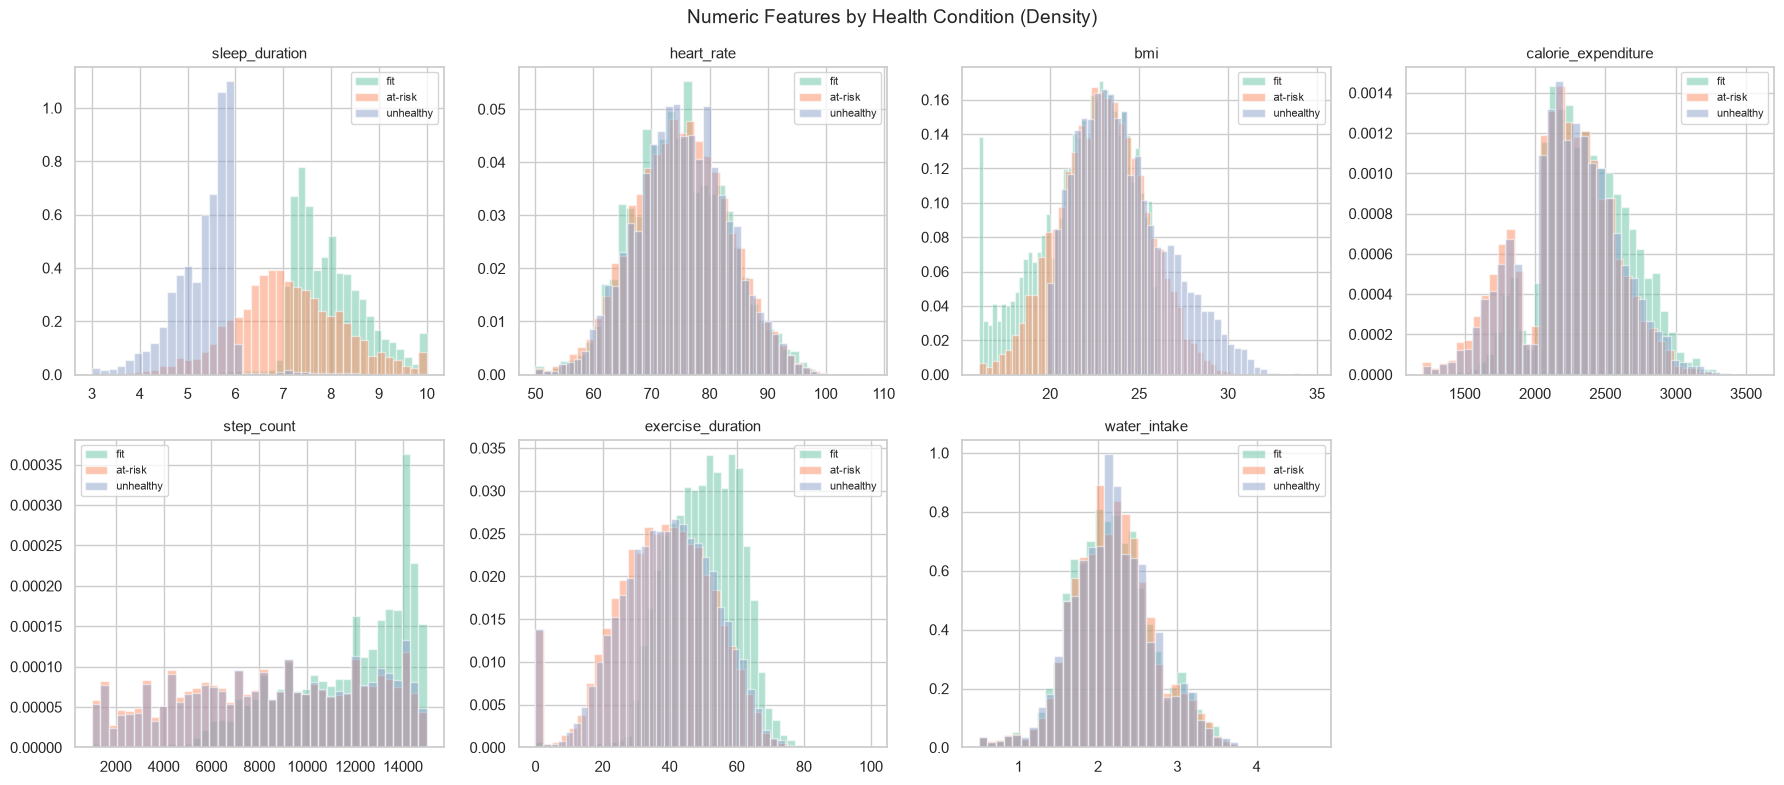

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    for label in CLASS_ORDER:
        subset = train.loc[train[TARGET] == label, col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, label=label, density=True, color=PALETTE[label])
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
axes[-1].set_visible(False)
fig.suptitle('Numeric Features by Health Condition (Density)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Numeric Features by Target — Boxplots

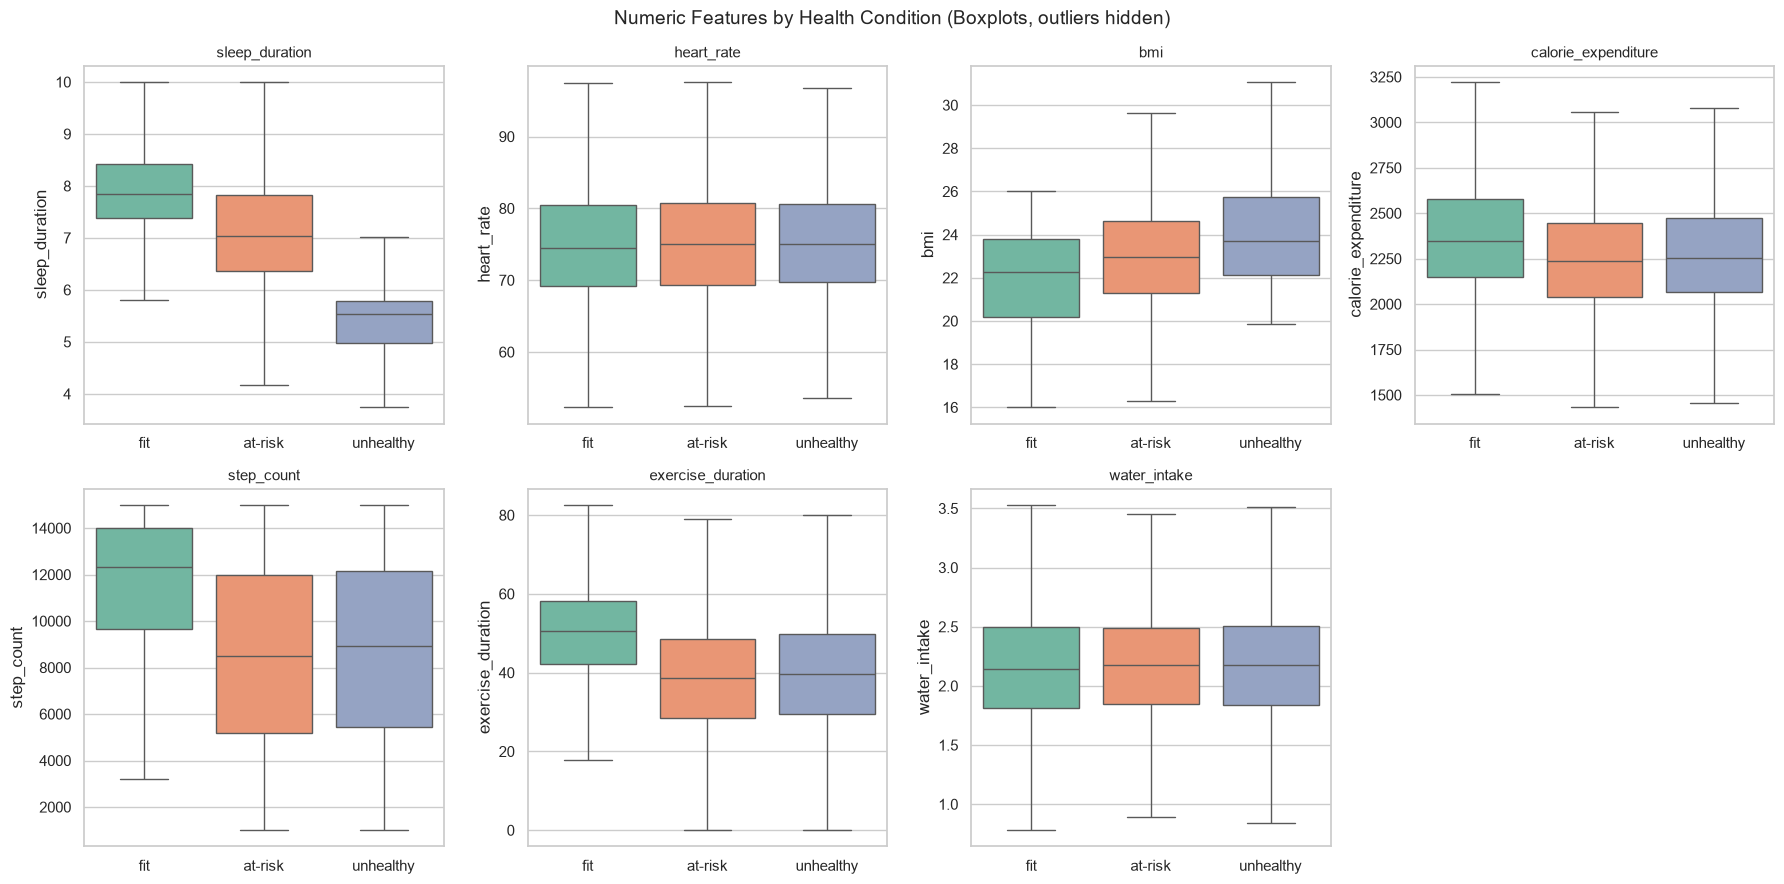

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASS_ORDER, ax=axes[i],
                palette=PALETTE, showfliers=False)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
fig.suptitle('Numeric Features by Health Condition (Boxplots, outliers hidden)', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Numeric Features by Target — Violin Plots

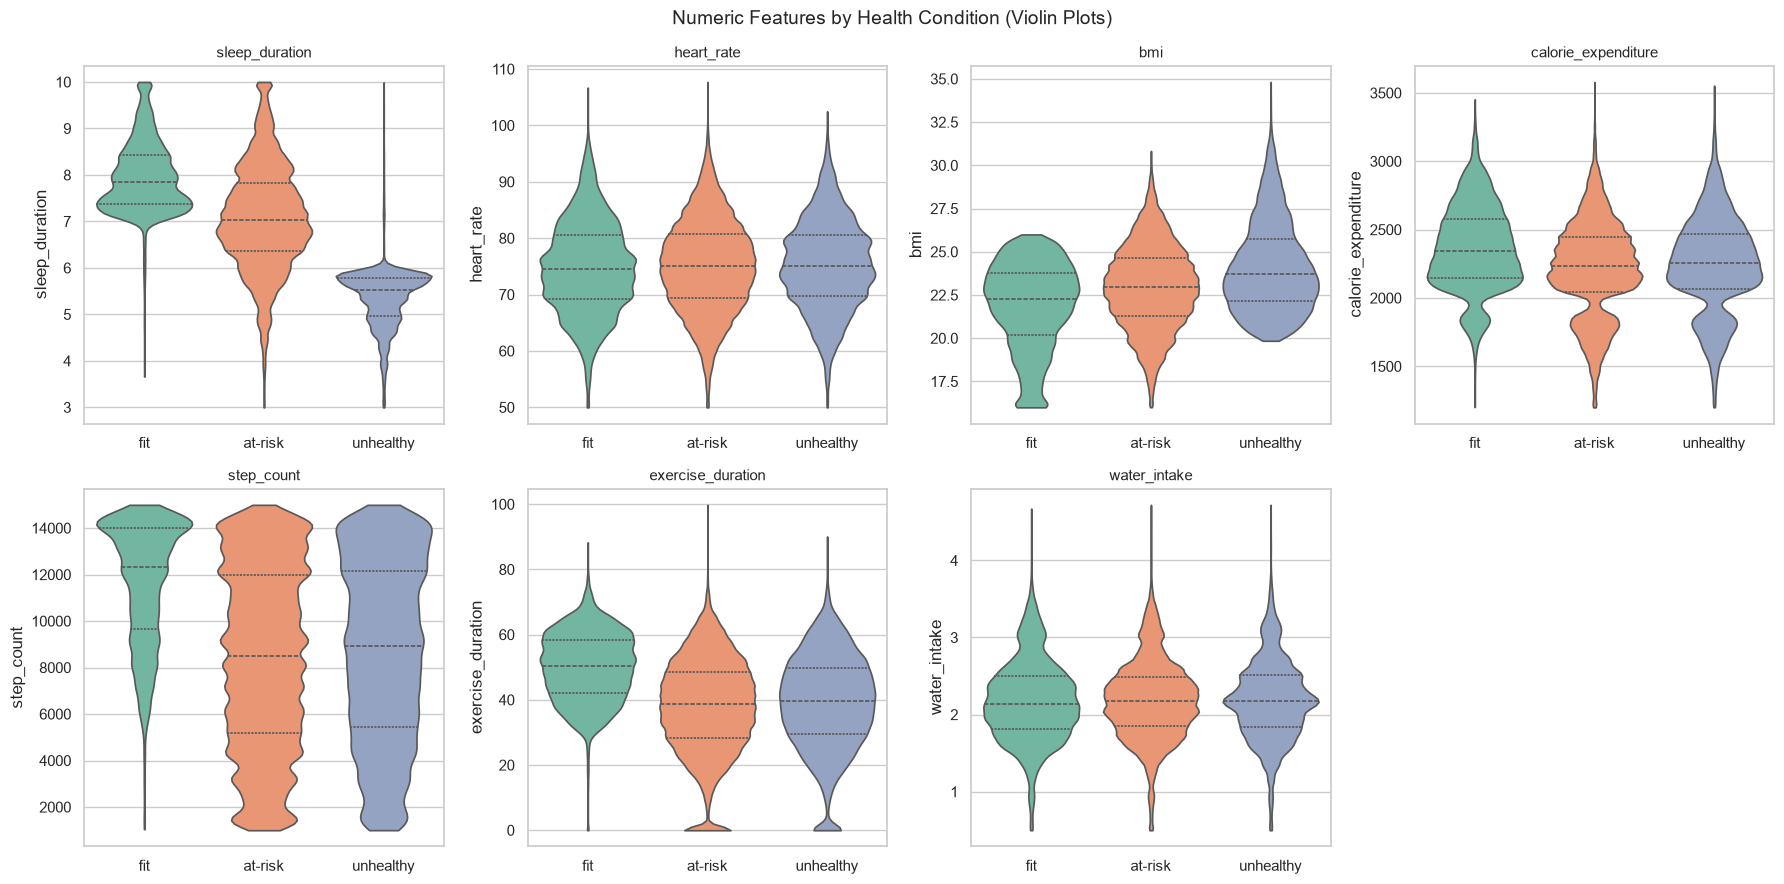

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    sns.violinplot(data=train, x=TARGET, y=col, order=CLASS_ORDER, ax=axes[i],
                    palette=PALETTE, cut=0, inner='quartile')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
fig.suptitle('Numeric Features by Health Condition (Violin Plots)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Outlier Screen (Boxplots, full range)

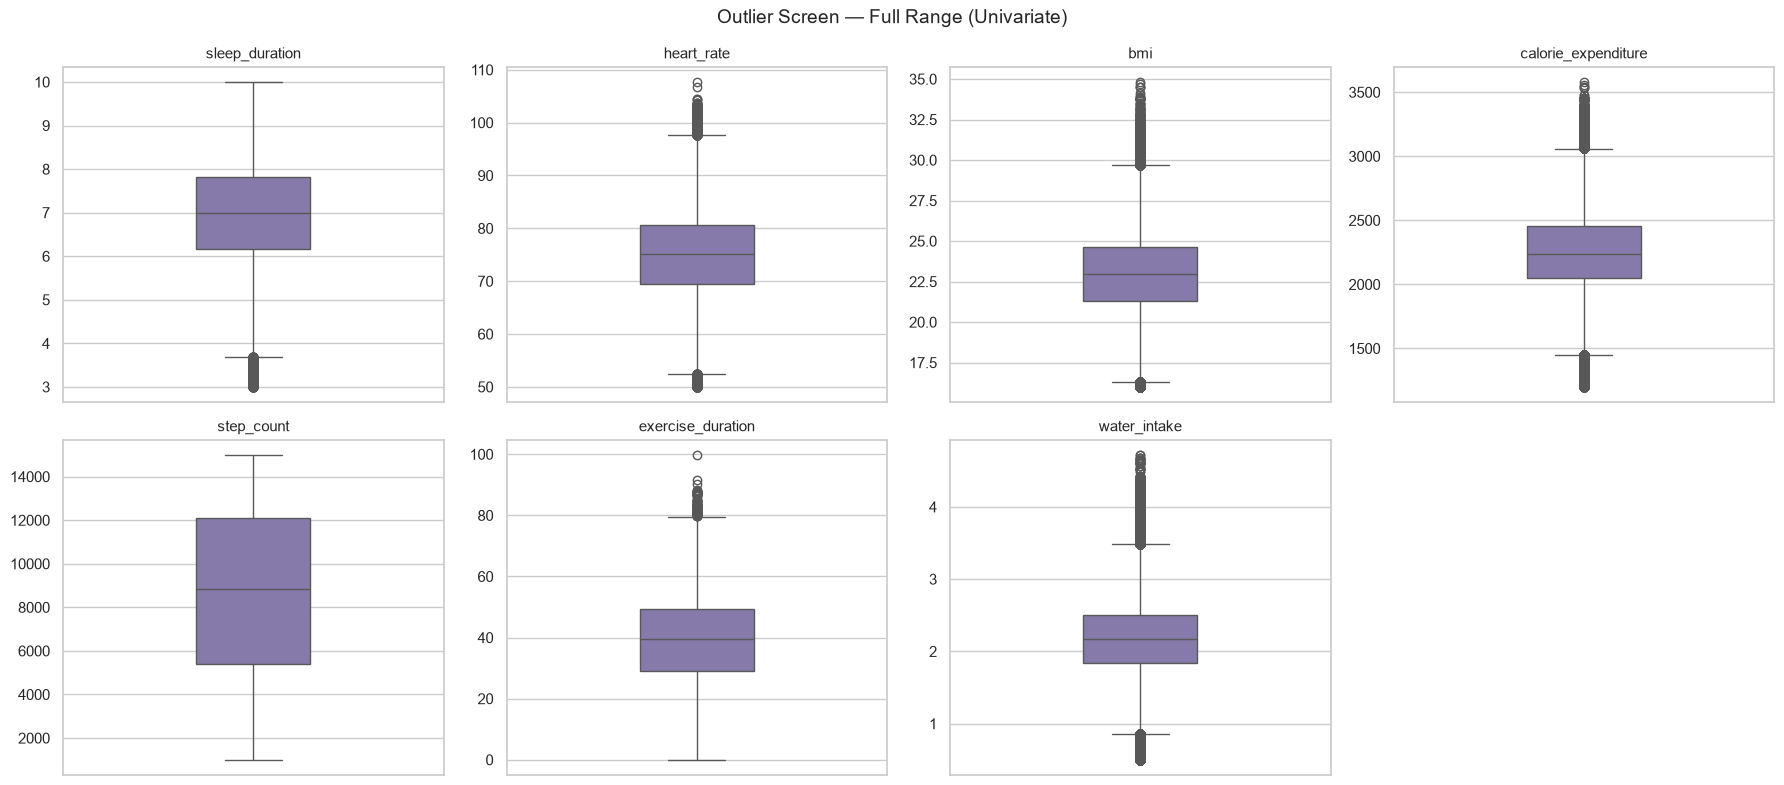

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    sns.boxplot(y=train[col].dropna(), ax=axes[i], color='#8172B2', width=0.3)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')
axes[-1].set_visible(False)
fig.suptitle('Outlier Screen — Full Range (Univariate)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Categorical Feature Distributions (Overall)

TypeError: 'value' must be an instance of str or bytes, not a float

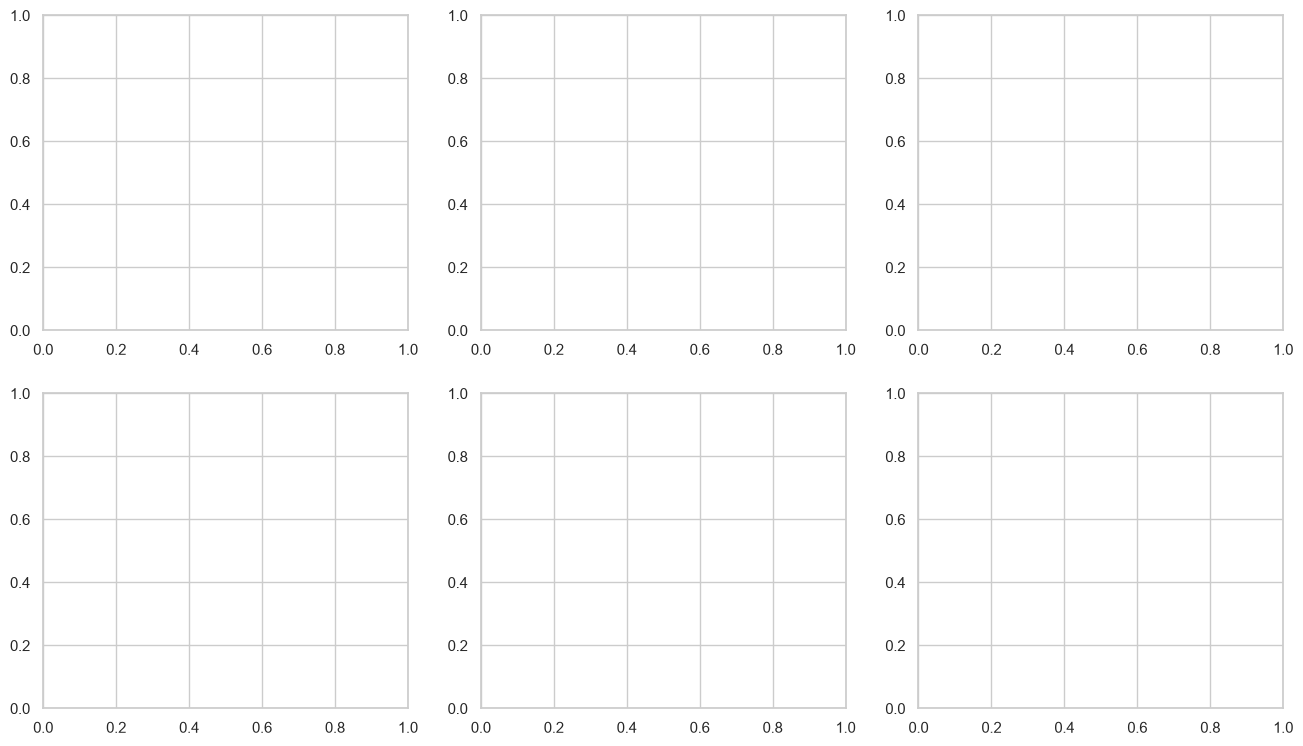

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(CAT_COLS):
    vc = train[col].value_counts(dropna=False)
    axes[i].bar(vc.index.astype(str), vc.values, color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
fig.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 12. Categorical Features vs Target

In [1]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(train[col], train[TARGET], normalize='index')[CLASS_ORDER] * 100
    ct.plot(kind='bar', ax=axes[i], color=[PALETTE[c] for c in CLASS_ORDER],
            edgecolor='white', width=0.7, legend=(i == 0))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within category')
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].legend(fontsize=8, title=TARGET)
fig.suptitle('Categorical Features vs Health Condition (%)', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 13. Correlation Heatmap (Numeric Features)

In [2]:
corr = train[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Numeric Feature Correlations', fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'train' is not defined

## 14. Pairwise Relationships

Sampled to 5,000 rows for a readable, fast-rendering scatter matrix.

In [ ]:
sample = train.sample(n=5000, random_state=42)
g = sns.pairplot(sample, vars=NUM_COLS, hue=TARGET, hue_order=CLASS_ORDER,
                  palette=PALETTE, diag_kind='kde', plot_kws=dict(alpha=0.4, s=12),
                  height=1.9)
g.fig.suptitle('Pairwise Relationships (5,000-row sample)', y=1.01, fontsize=14)
plt.show()

## 15. Key Observations

- **Class imbalance**: `at-risk` dominates (~86%), while `fit` and `unhealthy` are minority classes — worth stratifying CV folds and weighting/resampling in modeling.
- **Missingness**: several columns (`stress_level`, `sleep_quality`, `sleep_duration`, `calorie_expenditure`) have double-digit missing percentages; check the missingness-correlation heatmap above for whether it's MCAR or structurally linked across columns.
- **Numeric separability**: inspect the density/violin plots for features whose distributions shift visibly across classes (candidates for the strongest single-feature signal).
- **Correlated features**: any pair above ~|0.3| in the correlation heatmap is a candidate for interaction features or collinearity checks before linear models.
- **Categorical skew**: look for categories with very small counts in the distribution bars — those levels may need grouping before one-hot/target encoding.